This code modfies and adapts much of the code from three seperate locations Nick Byrnes' "CRAB-Optics" (https://github.com/drailin/CRAB-optics) Alexandra Higley, Nick Byrnes, and Dorothy Gan "Get Image Location_UVFS" Dorothy Gan "find_lens_locations.py

In [1]:
import numpy as np
import matplotlib 
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from matplotlib import cm
%matplotlib inline

Functions and Constants

The Sellmeier equation is used for different materials to find the index of refraction at varying wavelengths. The function takes in a given wavelenght and the material to find the index fo refraction for the medium. In general these results are taken from https://refractiveindex.info/ with the correct temperatures and "valid" wavelengths

In [2]:
def index_ref(wavelength, material):
    if material == 'MgF2': #Zheng et al. 2023 found for 220nm - 1700nm at 21 C
        n_sqr = (1 
               + 0.48755108*wavelength**2/(wavelength**2-0.04338408**2) 
               + 0.39875031*wavelength**2/(wavelength**2-0.09461442**2) 
               + 2.3120353*wavelength**2/(wavelength**2-23.793604**2) )
        
    elif material == 'CaF2': #Li 1980 found for 150nm to 12000 nm at 20C
        n_sqr = (1 
               + 0.33973 
               + 0.69913*wavelength**2/(wavelength**2-0.09374**2) 
               + 0.11994*wavelength**2/(wavelength**2-21.18**2) 
               + 4.35181*wavelength**2/(wavelength**2-38.46**2) )
        
    elif material == 'UVFS': #Fused Silica Malitson found at 210 nm to 6700 nm at 20 C
        n_sqr = (1 
               + 0.6961663*wavelength**2/(wavelength**2-0.0684043**2) 
               + 0.4079426*wavelength**2/(wavelength**2-0.1162414**2) 
               + 2.8974794*wavelength**2/(wavelength**2-9.896161**2) )

    return n_sqr

In [3]:
def one_lens_quantities(wl, material, R, EL_z, EL_h):
    n = np.sqrt(index_ref(wl, material))
    f = 1 / ((n - 1) / R)

    # lens position that forces the image onto the II
    disc = EL_z**2 - 4 * f * EL_z
    z_lens = (EL_z - np.sqrt(disc)) / 2   # branch closer to II

    s1 = EL_z - z_lens
    s2 = z_lens
    mag = -(s2 / s1)
    h_im = mag * EL_h

    return n, f, z_lens, mag, h_im

In [4]:
wl_range = np.arange(0.128, 0.8, 0.001)
wl_range_nm = wl_range * 1000

EL_Height = 419

EL_Vessel_Dist = 1219.2
EL_Lens1 = 1108.075
Periscope_Path = 165.118
Vessel_II = 152.4
Lens2_II = 50
Lens2_Motor = 200

TotalPath = EL_Vessel_Dist + Periscope_Path + Vessel_II

EL_z = TotalPath
Lens1_z = TotalPath - EL_Lens1

Lens2_range = np.linspace(Lens2_II, Lens2_II+Lens2_Motor, 300)

In [5]:
wl_range = np.arange(0.117, 1.1, 0.001)   # microns
wl_range_nm = wl_range * 1000
material = 'UVFS'
R1 = 34.39

n_vals = []
f_vals = []
lens_pos = []
mag_vals = []
h_vals = []

for wl in wl_range:
    n, f, z, m, h = one_lens_quantities(wl, material, R1, EL_z, EL_Height)
    n_vals.append(n)
    f_vals.append(f)
    lens_pos.append(z)
    mag_vals.append(m)
    h_vals.append(h)

wl_points = [0.128, 0.175]
wl_points_nm = [128, 175]
                  
n_points = []
f_points = []
lens_points = []
mag_points = []
h_points = []

for wl in wl_points:
    n, f, z, m, h = one_lens_quantities(wl, material, R1, EL_z, EL_Height)
    n_points.append(n)
    f_points.append(f)
    lens_points.append(z)
    mag_points.append(m)
    h_points.append(h)

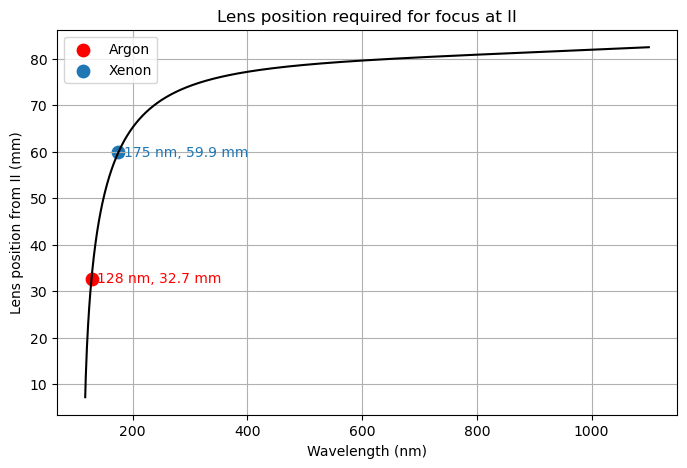

In [6]:
plt.figure(figsize=(8,5))
plt.plot(wl_range_nm, lens_pos, color="black")

point_colors = ["red", "tab:blue"]
point_labels = ["Argon", "Xenon"]

for x, y, c, lab in zip(wl_points_nm, lens_points, point_colors, point_labels):
    plt.scatter(x, y, color=c, s=80, label=lab)
    plt.text(x + 10, y, f"{x} nm, {y:.1f} mm", color=c, va='center')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Lens position from II (mm)")
plt.title("Lens position required for focus at II")
plt.legend()
plt.grid(True)
plt.show()

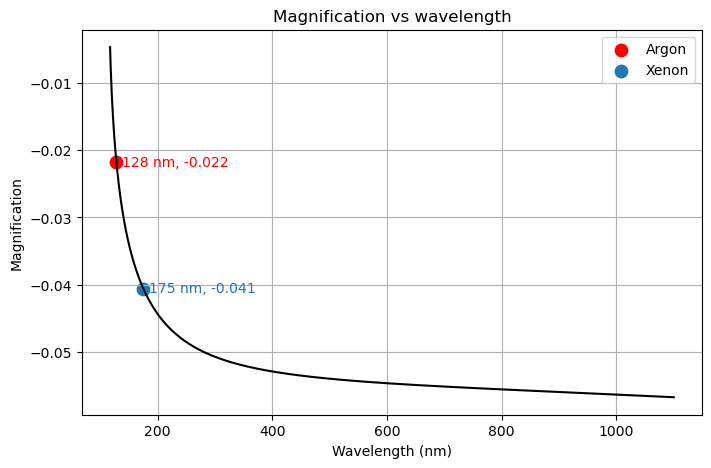

In [7]:
plt.figure(figsize=(8,5))
plt.plot(wl_range_nm, mag_vals, color="black")

for x, y, c, lab in zip(wl_points_nm, mag_points, point_colors, point_labels):
    plt.scatter(x, y, color=c, s=80, label=lab)
    plt.text(x + 10, y, f"{x} nm, {y:.3f}", color=c, va='center')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Magnification")
plt.title("Magnification vs wavelength")
plt.legend()
plt.grid(True)
plt.show()

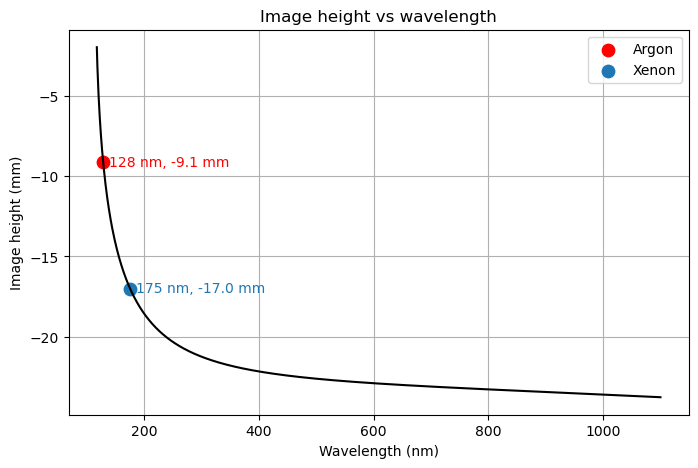

In [8]:
plt.figure(figsize=(8,5))
plt.plot(wl_range_nm, h_vals, color="black")

for x, y, c, lab in zip(wl_points_nm, h_points, point_colors, point_labels):
    plt.scatter(x, y, color=c, s=80, label=lab)
    plt.text(x + 10, y, f"{x} nm, {y:.1f} mm", color=c, va='center')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Image height (mm)")
plt.title("Image height vs wavelength")
plt.legend()
plt.grid(True)
plt.show()

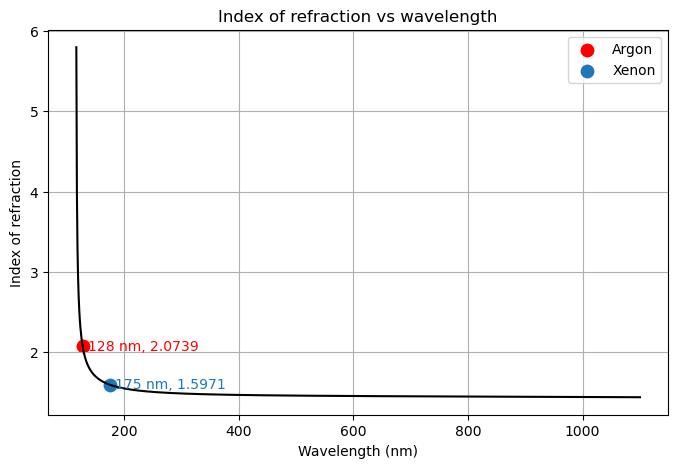

In [9]:
plt.figure(figsize=(8,5))
plt.plot(wl_range_nm, n_vals, color="black")

for x, y, c, lab in zip(wl_points_nm, n_points, point_colors, point_labels):
    plt.scatter(x, y, color=c, s=80, label=lab)
    plt.text(x + 10, y, f"{x} nm, {y:.4f}", color=c, va='center')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Index of refraction")
plt.title("Index of refraction vs wavelength")
plt.legend()
plt.grid(True)
plt.show()

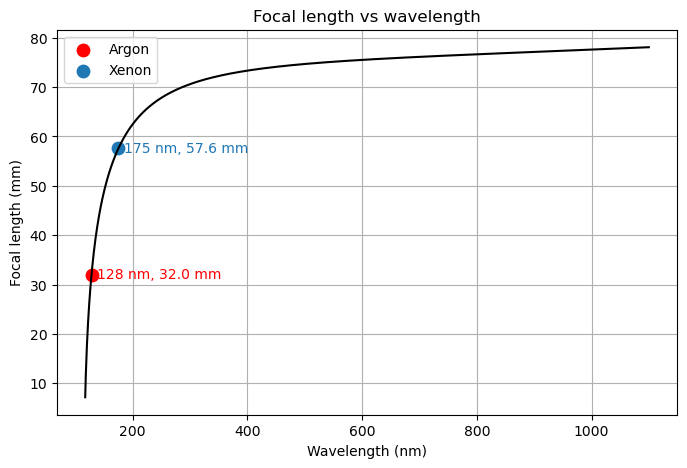

In [10]:
plt.figure(figsize=(8,5))
plt.plot(wl_range_nm, f_vals, color="black")

for x, y, c, lab in zip(wl_points_nm, f_points, point_colors, point_labels):
    plt.scatter(x, y, color=c, s=80, label=lab)
    plt.text(x + 10, y, f"{x} nm, {y:.1f} mm", color=c, va='center')

plt.xlabel("Wavelength (nm)")
plt.ylabel("Focal length (mm)")
plt.title("Focal length vs wavelength")
plt.legend()
plt.grid(True)
plt.show()

CRAB doesn't have only one lens it has two so I need to modify the function. Take the first image and make the the object for the second lens. 

In [11]:
def two_lens_system(wl, mat1, R1, Lens1_z, mat2, R2, Lens2_z, EL_z, EL_h):
    n1 = np.sqrt(index_ref(wl, mat1))
    n2 = np.sqrt(index_ref(wl, mat2))

    f1 = 1 / ((n1 - 1) / R1)
    f2 = 1 / ((n2 - 1) / R2)

    # lens 1
    s1_1 = EL_z - Lens1_z
    s2_1 = 1 / ((1 / f1) - (1 / s1_1))
    m1 = -(s2_1 / s1_1)
    h_im1 = m1 * EL_h
    z_im1 = Lens1_z - s2_1

    # lens 2
    s1_2 = z_im1 - Lens2_z
    s2_2 = 1 / ((1 / f2) - (1 / s1_2))
    m2 = -(s2_2 / s1_2)
    h_im2 = m2 * h_im1
    z_im2 = Lens2_z - s2_2

    return {"n1": n1,
        "n2": n2,
        "f1": f1,
        "f2": f2,
        "z_im1": z_im1,
        "h_im1": h_im1,
        "m1": m1,
        "Lens2_z": Lens2_z,
        "z_im2": z_im2,
        "final_z": z_im2,
        "m2": m2,
        "final_h": h_im2,
        "total_mag": m1 * m2}

In [12]:
focus_xe = []
focus_ar = []

mag_xe = []
mag_ar = []

h_xe = []
h_ar = []

for z2 in Lens2_range:
    res_xe = two_lens_system(wl=0.175,
        mat1='UVFS',
        R1=34.39,
        Lens1_z=Lens1_z,
        mat2='UVFS',
        R2=34.39,
        Lens2_z=z2,
        EL_z=EL_z,
        EL_h=EL_Height
    )
    res_ar = two_lens_system(
        wl=0.128,
        mat1='UVFS',
        R1=34.39,
        Lens1_z=Lens1_z,
        mat2='UVFS',
        R2=34.39,
        Lens2_z=z2,
        EL_z=EL_z,
        EL_h=EL_Height
    )

    focus_xe.append(res_xe["final_z"])
    focus_ar.append(res_ar["final_z"])
    mag_xe.append(res_xe["total_mag"])
    mag_ar.append(res_ar["total_mag"])
    h_xe.append(res_xe["final_h"])
    h_ar.append(res_ar["final_h"])

In [13]:
def zero_crossing(x, y):
    x = np.array(x)
    y = np.array(y)

    sign_change = np.where(np.diff(np.sign(y)) != 0)[0]

    if len(sign_change) == 0:
        return None

    i = sign_change[0]
    x1, x2 = x[i], x[i+1]
    y1, y2 = y[i], y[i+1]

    return x1 - y1 * (x2 - x1) / (y2 - y1)

z_cross_ar = zero_crossing(Lens2_range, focus_ar)
z_cross_xe = zero_crossing(Lens2_range, focus_xe)

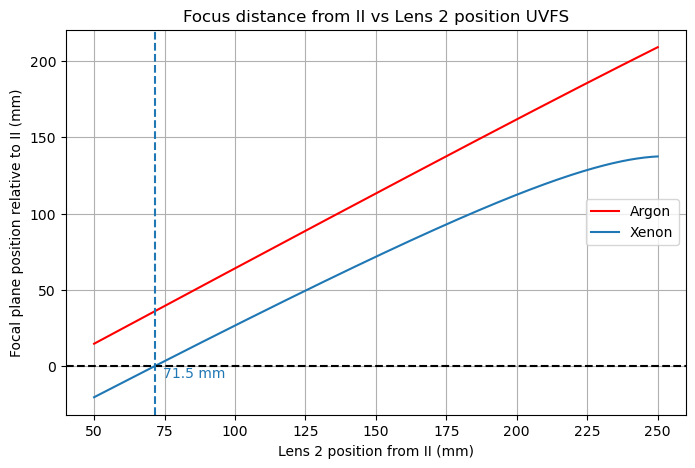

In [14]:
plt.figure(figsize=(8,5))
plt.plot(Lens2_range, focus_ar, color="red", label="Argon")
plt.plot(Lens2_range, focus_xe, color="tab:blue", label="Xenon")
plt.axhline(0, linestyle="--", color="black")

if z_cross_ar is not None:
    plt.axvline(z_cross_ar, linestyle="--", color="red")
    plt.text(
        z_cross_ar + 3, 0,
        f"{z_cross_ar:.1f} mm",
        color="red",
        va="bottom"
    )

if z_cross_xe is not None:
    plt.axvline(z_cross_xe, linestyle="--", color="tab:blue")
    plt.text(
        z_cross_xe + 3, 0,
        f"{z_cross_xe:.1f} mm",
        color="tab:blue",
        va="top"
    )

plt.xlabel("Lens 2 position from II (mm)")
plt.ylabel("Focal plane position relative to II (mm)")
plt.title("Focus distance from II vs Lens 2 position UVFS")
plt.legend()
plt.grid(True)
plt.show()

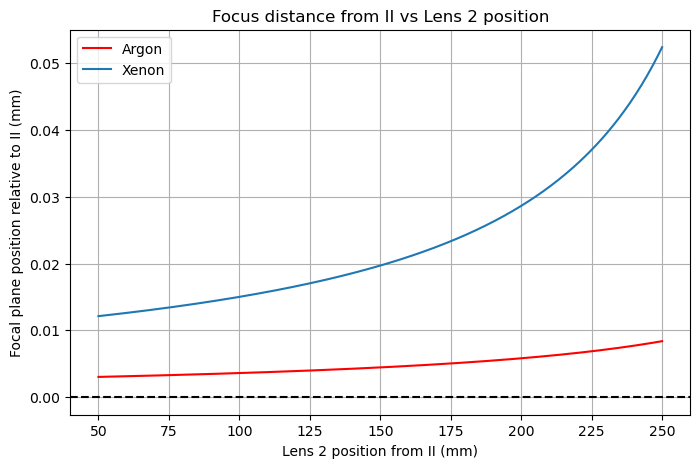

In [15]:
plt.figure(figsize=(8,5))
plt.plot(Lens2_range, mag_ar, color="red", label="Argon")
plt.plot(Lens2_range, mag_xe, color="tab:blue", label="Xenon")
plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Lens 2 position from II (mm)")
plt.ylabel("Focal plane position relative to II (mm)")
plt.title("Focus distance from II vs Lens 2 position")
plt.legend()
plt.grid(True)
plt.show()

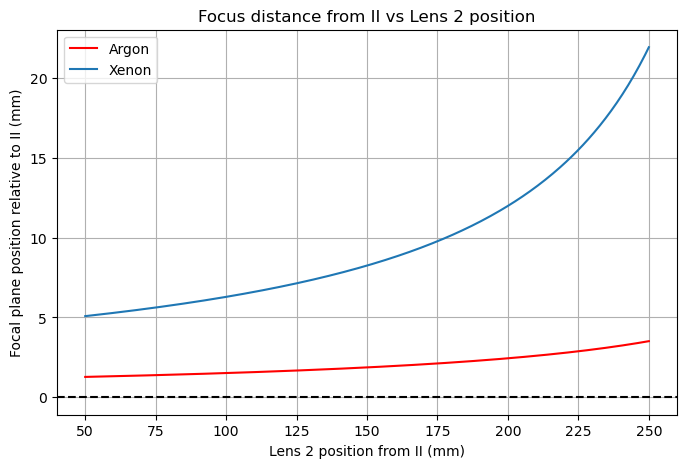

In [16]:
plt.figure(figsize=(8,5))
plt.plot(Lens2_range, h_ar, color="red", label="Argon")
plt.plot(Lens2_range, h_xe, color="tab:blue", label="Xenon")
plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Lens 2 position from II (mm)")
plt.ylabel("Focal plane position relative to II (mm)")
plt.title("Focus distance from II vs Lens 2 position")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
focus_xe = []
focus_ar = []

mag_xe = []
mag_ar = []

h_xe = []
h_ar = []

for z2 in Lens2_range:
    res_xe = two_lens_system(wl=0.175,
        mat1='CaF2',
        R1=43.4,
        Lens1_z=Lens1_z,
        mat2='CaF2',
        R2=43.4,
        Lens2_z=z2,
        EL_z=EL_z,
        EL_h=EL_Height
    )
    res_ar = two_lens_system(
        wl=0.128,
        mat1='CaF2',
        R1=43.4,
        Lens1_z=Lens1_z,
        mat2='CaF2',
        R2=43.4,
        Lens2_z=z2,
        EL_z=EL_z,
        EL_h=EL_Height
    )

    focus_xe.append(res_xe["final_z"])
    focus_ar.append(res_ar["final_z"])
    mag_xe.append(res_xe["total_mag"])
    mag_ar.append(res_ar["total_mag"])
    h_xe.append(res_xe["final_h"])
    h_ar.append(res_ar["final_h"])

In [18]:
z_cross_ar = zero_crossing(Lens2_range, focus_ar)
z_cross_xe = zero_crossing(Lens2_range, focus_xe)

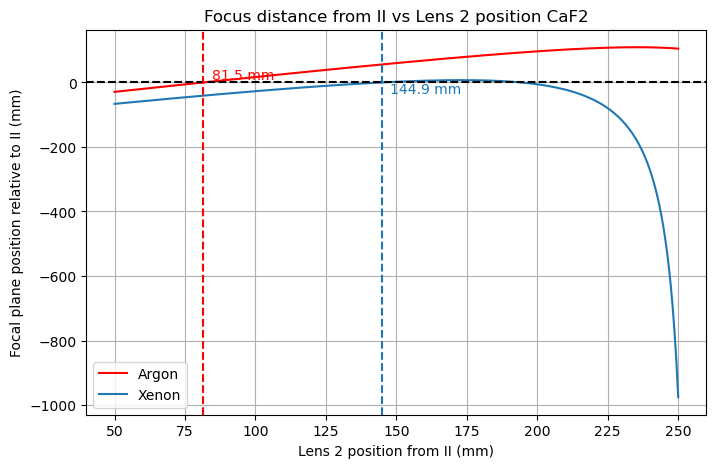

In [19]:
plt.figure(figsize=(8,5))
plt.plot(Lens2_range, focus_ar, color="red", label="Argon")
plt.plot(Lens2_range, focus_xe, color="tab:blue", label="Xenon")
plt.axhline(0, linestyle="--", color="black")

if z_cross_ar is not None:
    plt.axvline(z_cross_ar, linestyle="--", color="red")
    plt.text(
        z_cross_ar + 3, 0,
        f"{z_cross_ar:.1f} mm",
        color="red",
        va="bottom"
    )

if z_cross_xe is not None:
    plt.axvline(z_cross_xe, linestyle="--", color="tab:blue")
    plt.text(
        z_cross_xe + 3, 0,
        f"{z_cross_xe:.1f} mm",
        color="tab:blue",
        va="top"
    )

plt.xlabel("Lens 2 position from II (mm)")
plt.ylabel("Focal plane position relative to II (mm)")
plt.title("Focus distance from II vs Lens 2 position CaF2")
plt.legend()
plt.grid(True)
plt.show()